# Prophet Hyperparameter Tuning - All Datasets

This notebook performs grid search to find optimal Prophet hyperparameters for each HTTP request dataset independently.

## Install Dependencies

In [11]:
%pip install prophet scikit-learn pandas matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


## Imports

In [12]:
from pandas import read_csv
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import ParameterGrid
import numpy as np
import math
import datetime
import warnings
warnings.filterwarnings('ignore')

## Configuration

In [13]:
# Datasets to tune
DATASETS = [
    'trace1.csv',
    'trace5.csv',
    'trace10.csv',
    'trace15.csv',
    'trace20.csv',
    'trace25.csv',
    'trace30.csv',
    'trace35.csv',
    'trace40.csv',
    'trace45.csv',
    'trace50.csv',
    'trace55.csv',
    'trace60.csv',
]
DATA_PATH = './model_evaluation/http_requests_nasa/'

# Hyperparameter grid
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative'],
    'daily_seasonality': [True, False],
}

# For faster testing, use subset of data for validation
USE_SUBSET = True  # Set to False for full walk-forward validation
SUBSET_SIZE = 50   # Number of test points to use if USE_SUBSET=True

## Helper Functions

In [14]:
def evaluate_prophet_params(fileName, params, use_subset=True, subset_size=50):
    """
    Evaluate Prophet with given hyperparameters on a dataset.
    
    Args:
        fileName: Name of the CSV file
        params: Dictionary of Prophet hyperparameters
        use_subset: If True, only validate on subset_size test points
        subset_size: Number of test points to use for validation
    
    Returns:
        Dictionary with evaluation metrics
    """
    filename = DATA_PATH + fileName
    
    # Read the csv file
    dataset = read_csv(filename, header=0, parse_dates=[0], index_col=0, date_format='%d/%b/%Y:%H:%M:%S')
    
    # Split into train and test sets
    X = dataset.values.astype('float32')
    size = int(len(X) * 0.67)
    train, test = X[0:size], X[size:len(X)]
    
    # Get the index for dates
    dataset_dates = dataset.index
    train_dates = dataset_dates[0:size]
    test_dates = dataset_dates[size:len(X)]
    
    # Use subset for faster validation
    test_length = min(subset_size, len(test)) if use_subset else len(test)
    
    predictions = []
    start_time = datetime.datetime.now()
    
    # Walk-forward validation
    for t in range(test_length):
        # Prepare data for Prophet
        train_end_idx = size + t
        current_train_data = dataset.iloc[0:train_end_idx]
        
        df_prophet = pd.DataFrame({
            'ds': current_train_data.index,
            'y': current_train_data.values.flatten()
        })
        
        # Create and fit model with given parameters
        model = Prophet(
            changepoint_prior_scale=params['changepoint_prior_scale'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
            seasonality_mode=params['seasonality_mode'],
            daily_seasonality=params['daily_seasonality'],
            weekly_seasonality=False,
            yearly_seasonality=False
        )
        model.fit(df_prophet)
        
        # Make forecast for next time step
        future = pd.DataFrame({'ds': [test_dates[t]]})
        forecast = model.predict(future)
        
        yhat = forecast['yhat'].values[0]
        predictions.append(yhat)
    
    elapsed_time = datetime.datetime.now() - start_time
    
    # Evaluate forecasts
    yhat = np.asarray(predictions, dtype=np.float32)
    y_test = test[:test_length].flatten()
    
    mse = mean_squared_error(y_test, yhat)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_test, yhat)
    r2 = r2_score(y_test, yhat)
    
    return {
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'time_seconds': elapsed_time.total_seconds(),
        'predictions': predictions,
        'actuals': y_test
    }

## Run Grid Search

In [15]:
# Generate all parameter combinations
param_combinations = list(ParameterGrid(param_grid))
total_combinations = len(param_combinations)

print(f"Testing {total_combinations} hyperparameter combinations for {len(DATASETS)} datasets...")
print(f"Validation mode: {'Subset (' + str(SUBSET_SIZE) + ' points)' if USE_SUBSET else 'Full walk-forward'}")
print("="*80)

# Store results for all datasets
all_datasets_results = {}

for dataset_idx, dataset_name in enumerate(DATASETS, 1):
    print(f"\n{'='*80}")
    print(f"DATASET {dataset_idx}/{len(DATASETS)}: {dataset_name}")
    print(f"{'='*80}")
    
    results = []
    best_rmse = float('inf')
    best_params = None
    best_result = None
    
    for idx, params in enumerate(param_combinations, 1):
        print(f"[{idx}/{total_combinations}] Testing: {params}", end=" ")
        
        try:
            result = evaluate_prophet_params(
                dataset_name, 
                params, 
                use_subset=USE_SUBSET, 
                subset_size=SUBSET_SIZE
            )
            
            result['params'] = params
            result['dataset'] = dataset_name
            results.append(result)
            
            print(f"-> RMSE: {result['rmse']:.2f}, R2: {result['r2']:.4f}, MAE: {result['mae']:.2f}")
            
            # Track best parameters for this dataset
            if result['rmse'] < best_rmse:
                best_rmse = result['rmse']
                best_params = params
                best_result = result
                print(f"    ✓ New best RMSE for {dataset_name}!")
                
        except Exception as e:
            print(f"✗ Error: {str(e)}")
            continue
    
    # Store results for this dataset
    all_datasets_results[dataset_name] = {
        'all_results': results,
        'best_params': best_params,
        'best_result': best_result
    }
    
    print(f"\n🏆 BEST for {dataset_name}:")
    print(f"   Params: {best_params}")
    print(f"   RMSE: {best_result['rmse']:.2f}, R2: {best_result['r2']:.4f}, MAE: {best_result['mae']:.2f}")

print("\n" + "="*80)
print("Grid search complete for all datasets!")

Testing 80 hyperparameter combinations for 13 datasets...
Validation mode: Subset (50 points)

DATASET 1/13: trace1.csv
[1/80] Testing: {'changepoint_prior_scale': 0.001, 'daily_seasonality': True, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 0.01} 

14:12:08 - cmdstanpy - INFO - Chain [1] start processing
14:12:10 - cmdstanpy - INFO - Chain [1] done processing
14:12:10 - cmdstanpy - INFO - Chain [1] start processing
14:12:11 - cmdstanpy - INFO - Chain [1] done processing
14:12:11 - cmdstanpy - INFO - Chain [1] start processing
14:12:13 - cmdstanpy - INFO - Chain [1] done processing
14:12:13 - cmdstanpy - INFO - Chain [1] start processing
14:12:14 - cmdstanpy - INFO - Chain [1] done processing
14:12:14 - cmdstanpy - INFO - Chain [1] start processing
14:12:15 - cmdstanpy - INFO - Chain [1] done processing
14:12:15 - cmdstanpy - INFO - Chain [1] start processing
14:12:16 - cmdstanpy - INFO - Chain [1] done processing
14:12:16 - cmdstanpy - INFO - Chain [1] start processing
14:12:17 - cmdstanpy - INFO - Chain [1] done processing
14:12:17 - cmdstanpy - INFO - Chain [1] start processing
14:12:18 - cmdstanpy - INFO - Chain [1] done processing
14:12:18 - cmdstanpy - INFO - Chain [1] start processing
14:12:19 - cmdstanpy - INFO - Chain [1]

-> RMSE: 31.42, R2: -0.9645, MAE: 24.67
    ✓ New best RMSE for trace1.csv!
[2/80] Testing: {'changepoint_prior_scale': 0.001, 'daily_seasonality': True, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 0.1} 

14:13:00 - cmdstanpy - INFO - Chain [1] start processing
14:13:01 - cmdstanpy - INFO - Chain [1] done processing
14:13:01 - cmdstanpy - INFO - Chain [1] start processing
14:13:02 - cmdstanpy - INFO - Chain [1] done processing
14:13:02 - cmdstanpy - INFO - Chain [1] start processing
14:13:03 - cmdstanpy - INFO - Chain [1] done processing
14:13:03 - cmdstanpy - INFO - Chain [1] start processing
14:13:04 - cmdstanpy - INFO - Chain [1] done processing
14:13:04 - cmdstanpy - INFO - Chain [1] start processing
14:13:05 - cmdstanpy - INFO - Chain [1] done processing
14:13:05 - cmdstanpy - INFO - Chain [1] start processing
14:13:06 - cmdstanpy - INFO - Chain [1] done processing
14:13:06 - cmdstanpy - INFO - Chain [1] start processing
14:13:07 - cmdstanpy - INFO - Chain [1] done processing
14:13:07 - cmdstanpy - INFO - Chain [1] start processing
14:13:08 - cmdstanpy - INFO - Chain [1] done processing
14:13:08 - cmdstanpy - INFO - Chain [1] start processing
14:13:09 - cmdstanpy - INFO - Chain [1]

-> RMSE: 31.37, R2: -0.9572, MAE: 24.56
    ✓ New best RMSE for trace1.csv!
[3/80] Testing: {'changepoint_prior_scale': 0.001, 'daily_seasonality': True, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 1.0} 

...

-> RMSE: 1498.90, R2: -0.0928, MAE: 1380.62
[79/80] Testing: {'changepoint_prior_scale': 0.5, 'daily_seasonality': False, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 1.0} 

19:51:34 - cmdstanpy - INFO - Chain [1] done processing
19:51:34 - cmdstanpy - INFO - Chain [1] start processing
19:51:34 - cmdstanpy - INFO - Chain [1] done processing
19:51:34 - cmdstanpy - INFO - Chain [1] start processing
19:51:34 - cmdstanpy - INFO - Chain [1] done processing
19:51:34 - cmdstanpy - INFO - Chain [1] start processing
19:51:34 - cmdstanpy - INFO - Chain [1] done processing
19:51:34 - cmdstanpy - INFO - Chain [1] start processing
19:51:34 - cmdstanpy - INFO - Chain [1] done processing
19:51:34 - cmdstanpy - INFO - Chain [1] start processing
19:51:34 - cmdstanpy - INFO - Chain [1] done processing
19:51:34 - cmdstanpy - INFO - Chain [1] start processing
19:51:34 - cmdstanpy - INFO - Chain [1] done processing
19:51:34 - cmdstanpy - INFO - Chain [1] start processing
19:51:34 - cmdstanpy - INFO - Chain [1] done processing
19:51:34 - cmdstanpy - INFO - Chain [1] start processing
19:51:34 - cmdstanpy - INFO - Chain [1] done processing
19:51:34 - cmdstanpy - INFO - Chain [1] 

-> RMSE: 1498.90, R2: -0.0928, MAE: 1380.62
[80/80] Testing: {'changepoint_prior_scale': 0.5, 'daily_seasonality': False, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 10.0} 

19:51:37 - cmdstanpy - INFO - Chain [1] done processing
19:51:37 - cmdstanpy - INFO - Chain [1] start processing
19:51:37 - cmdstanpy - INFO - Chain [1] done processing
19:51:37 - cmdstanpy - INFO - Chain [1] start processing
19:51:37 - cmdstanpy - INFO - Chain [1] done processing
19:51:37 - cmdstanpy - INFO - Chain [1] start processing
19:51:37 - cmdstanpy - INFO - Chain [1] done processing
19:51:37 - cmdstanpy - INFO - Chain [1] start processing
19:51:37 - cmdstanpy - INFO - Chain [1] done processing
19:51:37 - cmdstanpy - INFO - Chain [1] start processing
19:51:37 - cmdstanpy - INFO - Chain [1] done processing
19:51:37 - cmdstanpy - INFO - Chain [1] start processing
19:51:37 - cmdstanpy - INFO - Chain [1] done processing
19:51:37 - cmdstanpy - INFO - Chain [1] start processing
19:51:37 - cmdstanpy - INFO - Chain [1] done processing
19:51:37 - cmdstanpy - INFO - Chain [1] start processing
19:51:37 - cmdstanpy - INFO - Chain [1] done processing
19:51:37 - cmdstanpy - INFO - Chain [1] 

-> RMSE: 1498.90, R2: -0.0928, MAE: 1380.62

🏆 BEST for trace60.csv:
   Params: {'changepoint_prior_scale': 0.01, 'daily_seasonality': True, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 1.0}
   RMSE: 456.03, R2: 0.8988, MAE: 366.45

Grid search complete for all datasets!


## Results Summary

In [16]:
# Create summary dataframe with best parameters for each dataset
summary_data = []
for dataset_name, data in all_datasets_results.items():
    best = data['best_result']
    params = data['best_params']
    summary_data.append({
        'dataset': dataset_name,
        'changepoint_prior_scale': params['changepoint_prior_scale'],
        'seasonality_prior_scale': params['seasonality_prior_scale'],
        'seasonality_mode': params['seasonality_mode'],
        'daily_seasonality': params['daily_seasonality'],
        'rmse': best['rmse'],
        'mae': best['mae'],
        'r2': best['r2'],
        'mse': best['mse']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('rmse')

print("\n🏆 BEST HYPERPARAMETERS FOR EACH DATASET:")
print("="*80)
display(summary_df)


🏆 BEST HYPERPARAMETERS FOR EACH DATASET:


,dataset,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,daily_seasonality,rmse,mae,r2,mse
0,trace1.csv,0.010,0.10,multiplicative,True,22.507265,16.724173,-0.007723,506.576965
1,trace5.csv,0.050,0.10,multiplicative,True,57.540511,47.536064,-0.091059,3310.910400
2,trace10.csv,0.500,1.00,multiplicative,True,125.998159,98.891365,0.462731,15875.536133
3,trace15.csv,0.001,10.00,additive,True,165.348437,128.882584,0.730935,27340.105469
5,trace25.csv,0.001,1.00,additive,True,180.226463,133.600464,0.921251,32481.578125
4,trace20.csv,0.001,0.10,additive,True,199.130601,155.243103,0.832426,39652.996094
6,trace30.csv,0.001,1.00,additive,True,248.732545,188.531235,0.885077,61867.878906
7,trace35.csv,0.001,0.01,additive,True,261.549484,205.677200,0.908353,68408.132812
8,trace40.csv,0.001,0.10,additive,True,326.223742,270.601959,0.885451,106421.929688
9,trace45.csv,0.010,1.00,additive,True,369.311924,294.430145,0.877783,136391.296875


In [17]:
# Show detailed breakdown for each dataset
print("\n📊 DETAILED RESULTS BY DATASET:")
print("="*80)

for dataset_name in DATASETS:
    data = all_datasets_results[dataset_name]
    best_params = data['best_params']
    best_result = data['best_result']
    
    print(f"\n{dataset_name}:")
    print(f"  Best Hyperparameters:")
    for key, value in best_params.items():
        print(f"    {key}: {value}")
    print(f"  Performance:")
    print(f"    RMSE: {best_result['rmse']:.2f}")
    print(f"    MAE: {best_result['mae']:.2f}")
    print(f"    R²: {best_result['r2']:.4f}")
    print(f"    MSE: {best_result['mse']:.2f}")


📊 DETAILED RESULTS BY DATASET:

trace1.csv:
  Best Hyperparameters:
    changepoint_prior_scale: 0.01
    daily_seasonality: True
    seasonality_mode: multiplicative
    seasonality_prior_scale: 0.1
  Performance:
    RMSE: 22.51
    MAE: 16.72
    R²: -0.0077
    MSE: 506.58

trace5.csv:
  Best Hyperparameters:
    changepoint_prior_scale: 0.05
    daily_seasonality: True
    seasonality_mode: multiplicative
    seasonality_prior_scale: 0.1
  Performance:
    RMSE: 57.54
    MAE: 47.54
    R²: -0.0911
    MSE: 3310.91

trace10.csv:
  Best Hyperparameters:
    changepoint_prior_scale: 0.5
    daily_seasonality: True
    seasonality_mode: multiplicative
    seasonality_prior_scale: 1.0
  Performance:
    RMSE: 126.00
    MAE: 98.89
    R²: 0.4627
    MSE: 15875.54

trace15.csv:
  Best Hyperparameters:
    changepoint_prior_scale: 0.001
    daily_seasonality: True
    seasonality_mode: additive
    seasonality_prior_scale: 10.0
  Performance:
    RMSE: 165.35
    MAE: 128.88
    R²: 0.

## Visualize Best Model Performance

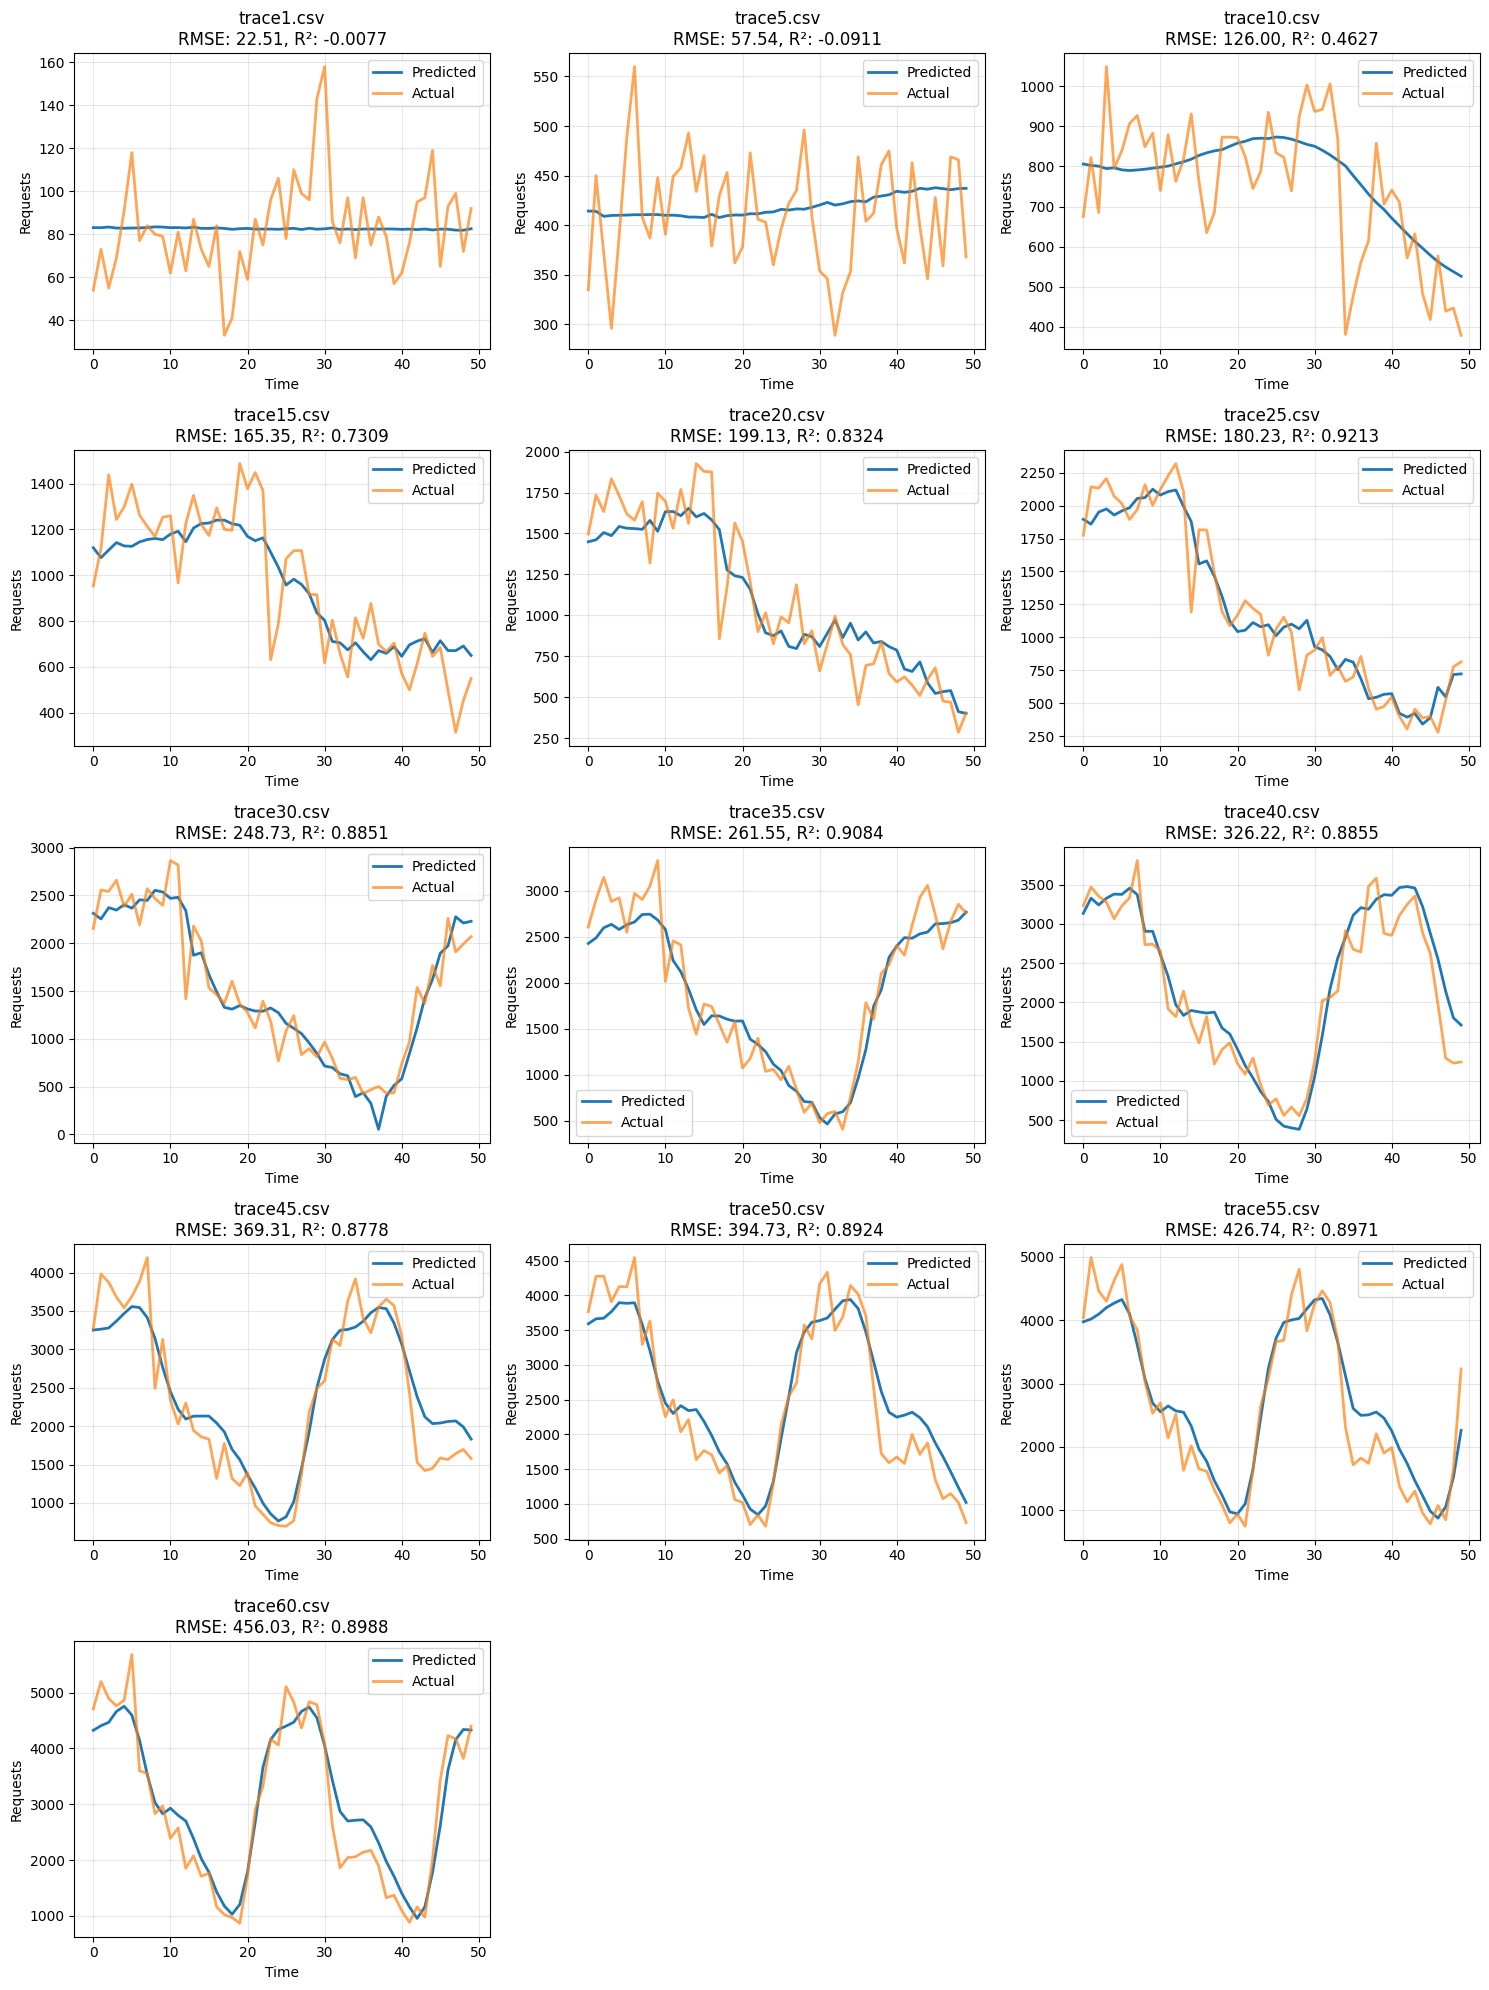

In [18]:
# Plot predictions vs actuals for each dataset's best model
num_datasets = len(DATASETS)
cols = 3
rows = (num_datasets + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten() if num_datasets > 1 else [axes]

for idx, dataset_name in enumerate(DATASETS):
    best_result = all_datasets_results[dataset_name]['best_result']
    
    sample_size = min(100, len(best_result['actuals']))
    axes[idx].plot(best_result['predictions'][-sample_size:], label='Predicted', linewidth=2)
    axes[idx].plot(best_result['actuals'][-sample_size:], label='Actual', linewidth=2, alpha=0.7)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylabel('Requests')
    axes[idx].set_xlabel('Time')
    axes[idx].set_title(f'{dataset_name}\nRMSE: {best_result["rmse"]:.2f}, R²: {best_result["r2"]:.4f}')

# Hide extra subplots
for idx in range(num_datasets, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Hyperparameter Impact Analysis

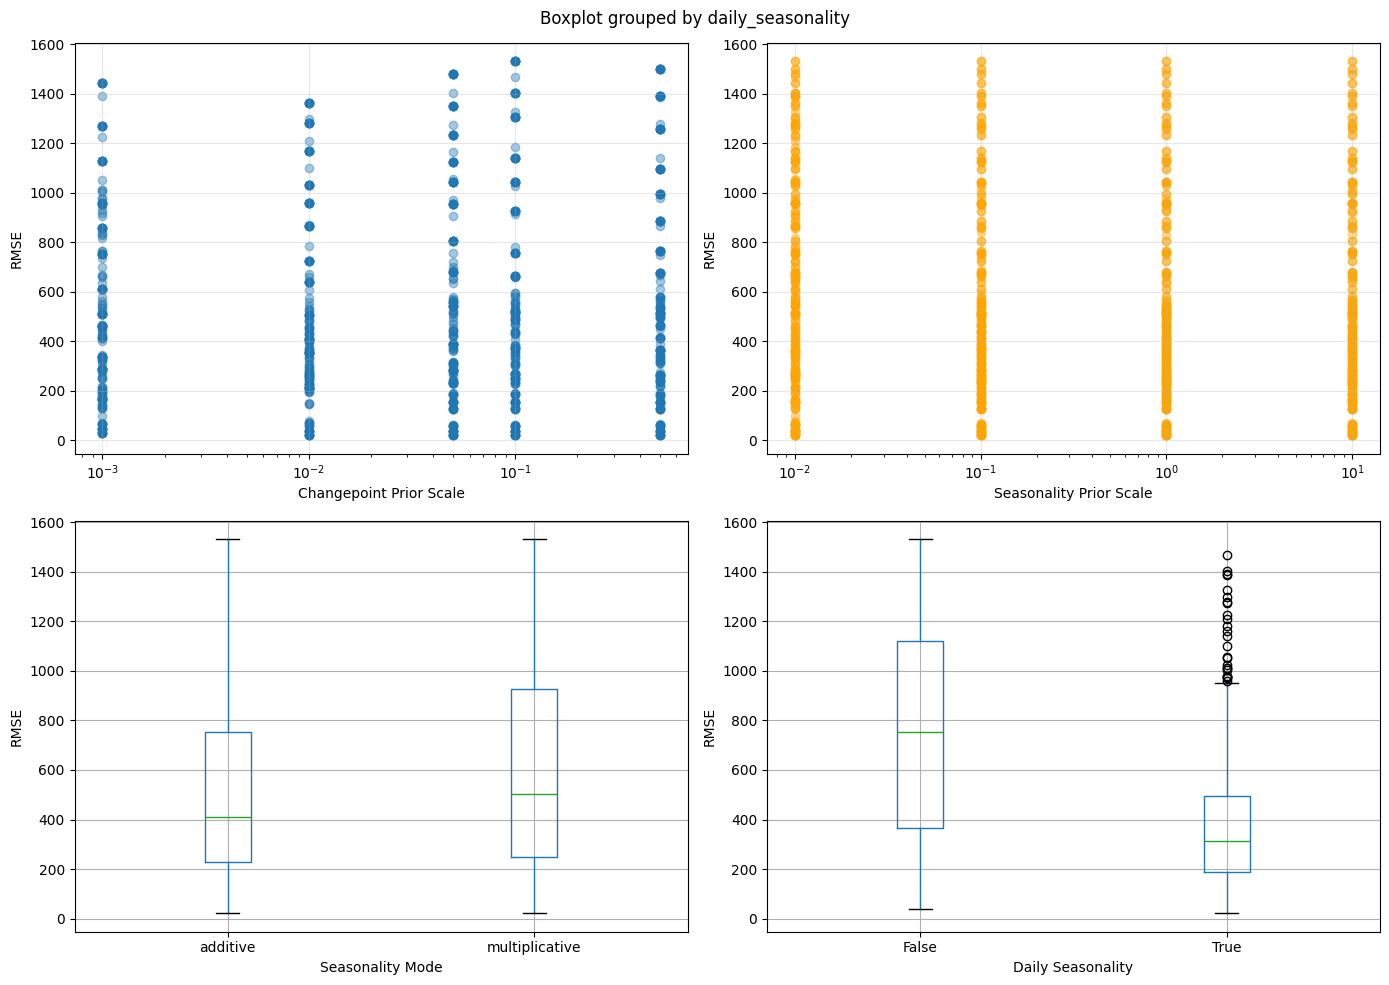

In [19]:
# Analyze hyperparameter impact across all datasets
all_results_combined = []
for dataset_name, data in all_datasets_results.items():
    for result in data['all_results']:
        all_results_combined.append({
            'dataset': dataset_name,
            **result['params'],
            'rmse': result['rmse'],
            'mae': result['mae'],
            'r2': result['r2']
        })

combined_df = pd.DataFrame(all_results_combined)

# Plot hyperparameter impact
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Hyperparameter Impact on RMSE (All Datasets)', fontsize=14, fontweight='bold')

# Changepoint prior scale
axes[0, 0].scatter(combined_df['changepoint_prior_scale'], combined_df['rmse'], alpha=0.4)
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel('Changepoint Prior Scale')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].grid(True, alpha=0.3)

# Seasonality prior scale
axes[0, 1].scatter(combined_df['seasonality_prior_scale'], combined_df['rmse'], alpha=0.4, color='orange')
axes[0, 1].set_xscale('log')
axes[0, 1].set_xlabel('Seasonality Prior Scale')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].grid(True, alpha=0.3)

# Seasonality mode
combined_df.boxplot(column='rmse', by='seasonality_mode', ax=axes[1, 0])
axes[1, 0].set_xlabel('Seasonality Mode')
axes[1, 0].set_ylabel('RMSE')
axes[1, 0].set_title('')

# Daily seasonality
combined_df.boxplot(column='rmse', by='daily_seasonality', ax=axes[1, 1])
axes[1, 1].set_xlabel('Daily Seasonality')
axes[1, 1].set_ylabel('RMSE')
axes[1, 1].set_title('')

plt.tight_layout()
plt.show()

## Save Results

In [20]:
# Save summary results (best params for each dataset) to CSV
summary_df.to_csv('prophet_best_params_per_dataset.csv', index=False)
print("✓ Best parameters per dataset saved to: prophet_best_params_per_dataset.csv")

# Save all results (all combinations for all datasets) to CSV
combined_df.to_csv('prophet_all_hyperparameter_results.csv', index=False)
print("✓ All hyperparameter results saved to: prophet_all_hyperparameter_results.csv")

# Save best parameters to text file for easy reference
with open('best_prophet_params_all_datasets.txt', 'w') as f:
    f.write("Best Prophet Hyperparameters for Each Dataset\n")
    f.write("="*80 + "\n\n")
    
    for dataset_name in DATASETS:
        data = all_datasets_results[dataset_name]
        best_params = data['best_params']
        best_result = data['best_result']
        
        f.write(f"\n{dataset_name}:\n")
        f.write(f"  Hyperparameters:\n")
        for key, value in best_params.items():
            f.write(f"    {key}: {value}\n")
        f.write(f"  Performance:\n")
        f.write(f"    RMSE: {best_result['rmse']:.2f}\n")
        f.write(f"    MAE: {best_result['mae']:.2f}\n")
        f.write(f"    R²: {best_result['r2']:.4f}\n")
        f.write(f"    MSE: {best_result['mse']:.2f}\n")
        f.write(f"  {'-'*60}\n")

print("✓ Best parameters summary saved to: best_prophet_params_all_datasets.txt")

print("\n" + "="*80)
print("All results saved successfully!")

✓ Best parameters per dataset saved to: prophet_best_params_per_dataset.csv
✓ All hyperparameter results saved to: prophet_all_hyperparameter_results.csv
✓ Best parameters summary saved to: best_prophet_params_all_datasets.txt

All results saved successfully!
